In [79]:
import sys
print(sys.executable)

import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

/Users/ericaking/opt/anaconda3/bin/python


In [81]:
df = pd.read_csv('GGXY.csv')

#remove rows without data
df.replace('-',np.nan,inplace=True)
df.dropna(inplace=True)

X = df.drop(['Club','Carry'],axis=1).astype(float) #only keep key metrics
y = df['Carry'].astype(float)

### Random Forest

            Feature  Importance
1        Ball Speed    0.413385
0        Club Speed    0.396100
2      Launch Angle    0.109206
3         Spin Rate    0.059075
7      Attack Angle    0.006349
5      Face to Path    0.005014
4        Face Angle    0.004513
6         Club Path    0.003663
8  Launch Direction    0.002696


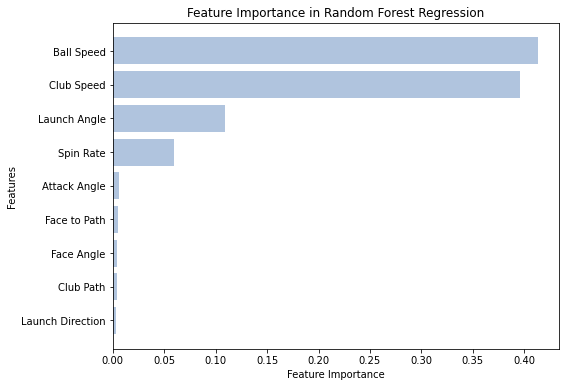

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

#standard random forest regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

#importances
feature_importances = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importances)

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='lightsteelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regression')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

Mean Squared Error: 82.3452
R-squared Score: 0.9548
            Feature  Importance
0        Club Speed    0.512501
1        Ball Speed    0.232793
2      Launch Angle    0.202627
3         Spin Rate    0.039212
5      Face to Path    0.005140
4        Face Angle    0.004111
6         Club Path    0.001798
7      Attack Angle    0.001207
8  Launch Direction    0.000611


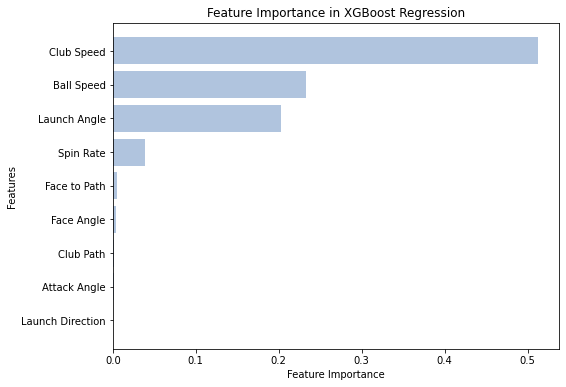

In [85]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset (assuming df is already preprocessed)
X = df.drop(['Club', 'Carry'], axis=1).astype(float)
y = df['Carry'].astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

# Initialize XGBoost Regressor with similar parameters to RandomForestRegressor
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

# Plot feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='lightsteelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in XGBoost Regression')
plt.gca().invert_yaxis()
plt.show()

### SVR

R-squared for Club Speed: 0.76361
Adjusted Optimal X ranges for maximizing Y on Club Speed: [(np.float64(99.89970941883767), np.float64(105.80970941883767))]


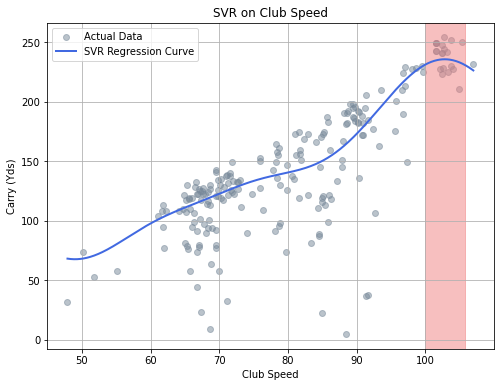

R-squared for Ball Speed: 0.92968
Adjusted Optimal X ranges for maximizing Y on Ball Speed: [(np.float64(147.32817635270538), np.float64(155.6)), (np.float64(147.9654509018036), np.float64(155.6))]


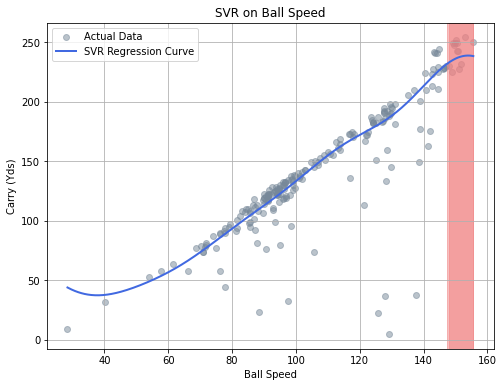

R-squared for Launch Angle: 0.10896
Adjusted Optimal X ranges for maximizing Y on Launch Angle: [(np.float64(9.956182364729461), np.float64(14.126182364729463)), (np.float64(10.123316633266533), np.float64(14.293316633266535))]


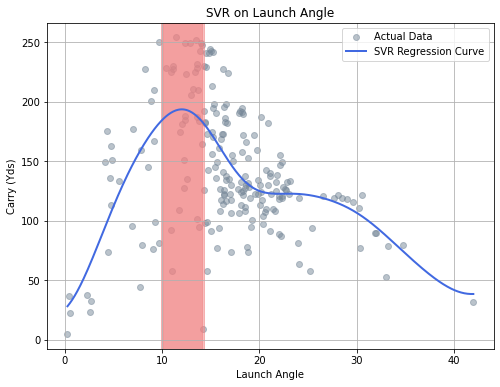

R-squared for Spin Rate: 0.01424
Adjusted Optimal X ranges for maximizing Y on Spin Rate: [(np.float64(4484.554108216433), np.float64(5545.554108216433)), (np.float64(4505.816633266533), np.float64(5566.816633266533))]


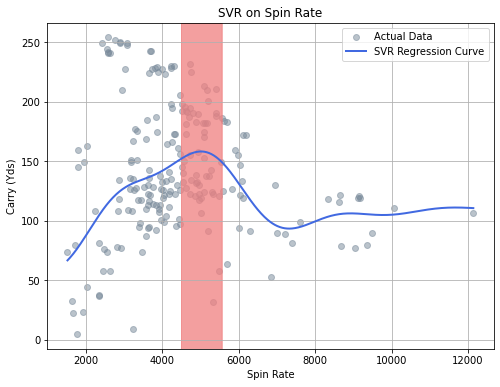

R-squared for Face Angle: 0.02175
Adjusted Optimal X ranges for maximizing Y on Face Angle: [(np.float64(-4.7271242484969935), np.float64(-0.9971242484969933)), (np.float64(-5.325120240480961), np.float64(-1.5951202404809612))]


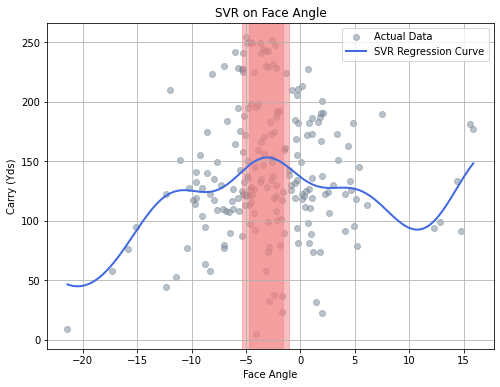

R-squared for Face to Path: 0.15649
Adjusted Optimal X ranges for maximizing Y on Face to Path: [(np.float64(-0.06398797595190597), np.float64(2.6760120240480942))]


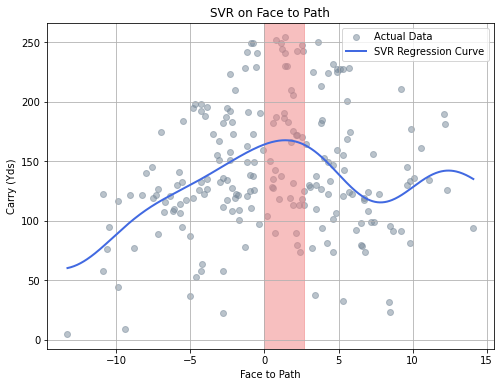

R-squared for Club Path: -0.06943
Adjusted Optimal X ranges for maximizing Y on Club Path: [(np.float64(-7.275651302605212), np.float64(-4.975651302605211)), (np.float64(-7.183466933867737), np.float64(-4.883466933867736))]


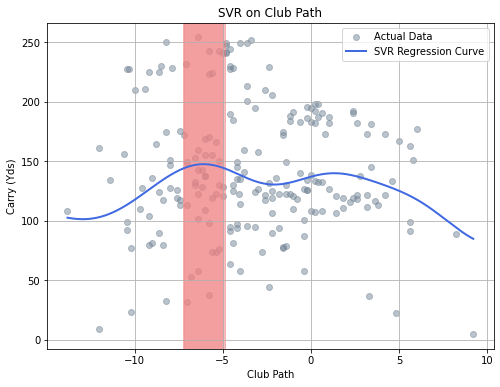

R-squared for Attack Angle: 0.09401
Adjusted Optimal X ranges for maximizing Y on Attack Angle: [(np.float64(-2.2570741482965935), np.float64(-0.4170741482965936))]


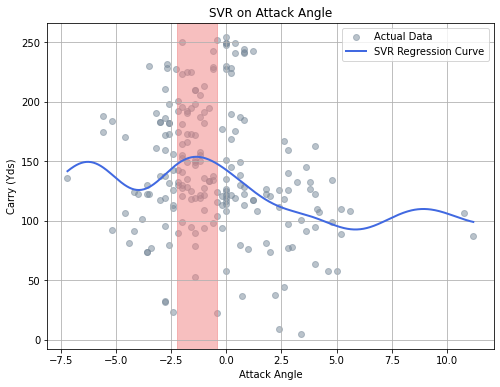

R-squared for Launch Direction: 0.01918
Adjusted Optimal X ranges for maximizing Y on Launch Direction: [(np.float64(12.559999999999999), np.float64(14.1)), (np.float64(12.436553106212422), np.float64(14.1))]


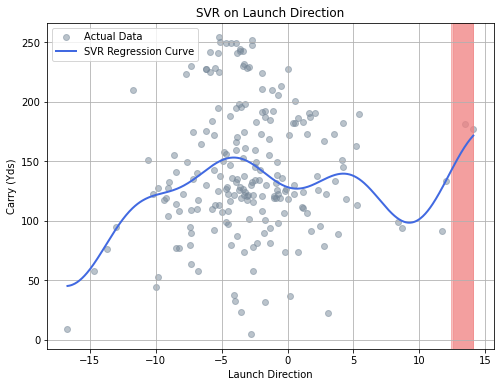

In [89]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

r2scores = []
optimal_ranges = []

for i in range(9):
    X_feature = X[X.columns[i]].to_numpy().reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=500)
    
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    svr = SVR(kernel='rbf')
    svr.fit(X_train_scaled, y_train_scaled) 

    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
    X_range = np.linspace(X_feature.min(), X_feature.max(), 500).reshape(-1, 1)
    X_range_scaled = scaler_X.transform(X_range)
    
    y_range_pred_scaled = svr.predict(X_range_scaled)
    y_range_pred = scaler_y.inverse_transform(y_range_pred_scaled.reshape(-1, 1)).ravel()
    
    r2 = r2_score(y_test, y_pred)
    r2scores.append(r2)
    print(f'R-squared for {X.columns[i]}: {r2:.5f}')
    
    # Identify the optimal X range that maximizes Y
    max_y = np.max(y_range_pred) 
    threshold = (0.98) * max_y  # threshold for "near max" regions
    
    optimal_x_values = X_range[y_range_pred >= threshold].flatten()
    
    discrete_ranges = []
    start = optimal_x_values[0]
    
    for j in range(1, len(optimal_x_values)):
        if optimal_x_values[j] - optimal_x_values[j - 1] > (X_range[1] - X_range[0]):
            discrete_ranges.append((start, optimal_x_values[j - 1]))
            start = optimal_x_values[j] 
    discrete_ranges.append((start, optimal_x_values[-1])) 
    
    # Limit to at most 2 optimal ranges based on predicted Y value
    discrete_ranges = sorted(
        discrete_ranges, key=lambda r: np.mean(y_range_pred[(X_range.flatten() >= r[0]) & (X_range.flatten() <= r[1])]), reverse=True
    )[:2]
    
    fixed_width = 0.1 * (X_feature.max() - X_feature.min()) 
    
    adjusted_ranges = []
    for r in discrete_ranges:
        mid_point = (r[0] + r[1]) / 2 
        new_start = max(X_feature.min(), mid_point - fixed_width / 2)
        new_end = min(X_feature.max(), mid_point + fixed_width / 2)
        adjusted_ranges.append((new_start, new_end))
    
    optimal_ranges.append((X.columns[i], adjusted_ranges))
    
    print(f"Adjusted Optimal X ranges for maximizing Y on {X.columns[i]}: {adjusted_ranges}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_feature, y, color='lightslategrey', alpha=0.5, label='Actual Data')
    plt.plot(X_range, y_range_pred, color='royalblue', lw=2, label='SVR Regression Curve')
    
    for r in adjusted_ranges:
        plt.axvspan(r[0], r[1], alpha=0.5, color='lightcoral')
    
    plt.xlabel(X.columns[i])
    plt.ylabel('Carry (Yds)')
    plt.title(f'SVR on {X.columns[i]}')
    plt.legend()
    plt.grid(True)
    plt.show()


### Finding Optimal Ranges

In [126]:
ranges_df = pd.DataFrame(optimal_ranges)
pd.set_option('display.max_rows', None)  # No limit on rows
pd.set_option('display.max_columns', None)  # No limit on columns
pd.set_option('display.width', None)  # No line wrapping for wide DataFrames
pd.set_option('display.max_colwidth', None)
display(ranges_df.transpose())

,0,1,2,3,4,5,6,7,8
0,Club Speed,Ball Speed,Launch Angle,Spin Rate,Face Angle,Face to Path,Club Path,Attack Angle,Launch Direction
1,"[(99.89970941883767, 105.80970941883767)]","[(147.32817635270538, 155.6), (147.9654509018036, 155.6)]","[(9.956182364729461, 14.126182364729463), (10.123316633266533, 14.293316633266535)]","[(4484.554108216433, 5545.554108216433), (4505.816633266533, 5566.816633266533)]","[(-4.7271242484969935, -0.9971242484969933), (-5.325120240480961, -1.5951202404809612)]","[(-0.06398797595190597, 2.6760120240480942)]","[(-7.275651302605212, -4.975651302605211), (-7.183466933867737, -4.883466933867736)]","[(-2.2570741482965935, -0.4170741482965936)]","[(12.559999999999999, 14.1), (12.436553106212422, 14.1)]"


### R-Squared

            Feature  R-squared
1        Ball Speed   0.929681
0        Club Speed   0.763610
5      Face to Path   0.156485
2      Launch Angle   0.108955
7      Attack Angle   0.094008
4        Face Angle   0.021751
8  Launch Direction   0.019185
3         Spin Rate   0.014243
6         Club Path  -0.069434


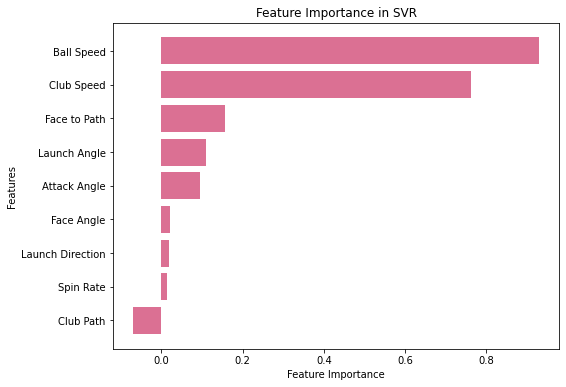

In [95]:
scores = pd.DataFrame({'Feature': X.columns,'R-squared': r2scores}).sort_values(by='R-squared', ascending=False)
print(scores)

plt.figure(figsize=(8, 6))
plt.barh(scores['Feature'], scores['R-squared'], color='palevioletred')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in SVR')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

### Heat maps

In [144]:
def create_heatmap(x, y, z, xlabel, ylabel, title):
    x = x.apply(pd.to_numeric, errors='coerce')
    y = y.apply(pd.to_numeric, errors='coerce')
    z = z.apply(pd.to_numeric, errors='coerce')

    heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=100, weights=z)
    counts, _, _ = np.histogram2d(x, y, bins=100)
    heatmap_avg = np.divide(heatmap_data, counts, out=np.zeros_like(heatmap_data), where=counts != 0)

    heatmap_smooth = scipy.ndimage.gaussian_filter(heatmap_avg, sigma=2.5)

    plt.figure(figsize=(8, 6))
    plt.imshow(
        heatmap_smooth.T, origin='lower', aspect='auto',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='inferno', interpolation="bilinear"
    )
    plt.colorbar(label='Carry (yards)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

    max_indices = np.unravel_index(np.argmax(heatmap_smooth), heatmap_smooth.shape)

    # Get the corresponding x and y values based on the max value position
    x_optimal = (xedges[max_indices[0]], xedges[max_indices[0] + 1])
    x_optimal = tuple([float(i) for i in my_tuple])
    y_optimal = (yedges[max_indices[1]], yedges[max_indices[1] + 1])

    print(f'Optimal {x.name} range:', x_optimal)
    print(f'Optimal {y.name} range:', y_optimal)

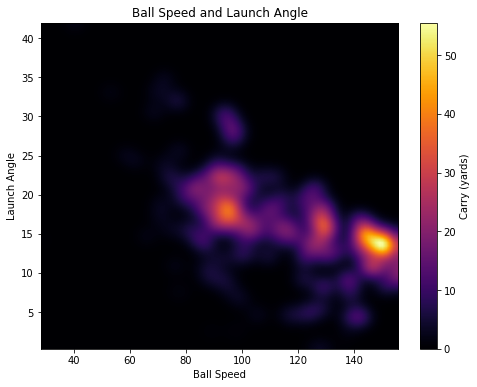

Optimal Ball Speed range: (np.float64(147.968), np.float64(149.23999999999998))
Optimal Launch Angle range: (np.float64(13.644000000000002), np.float64(14.061000000000002))


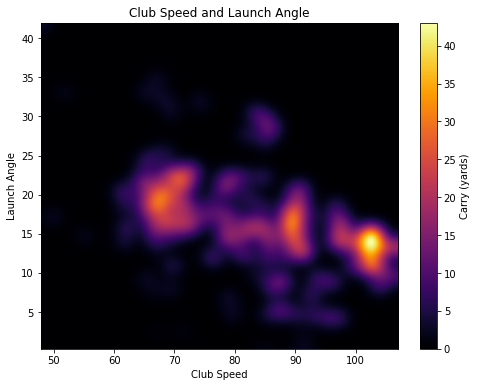

Optimal Club Speed range: (np.float64(102.27199999999999), np.float64(102.863))
Optimal Launch Angle range: (np.float64(13.644000000000002), np.float64(14.061000000000002))


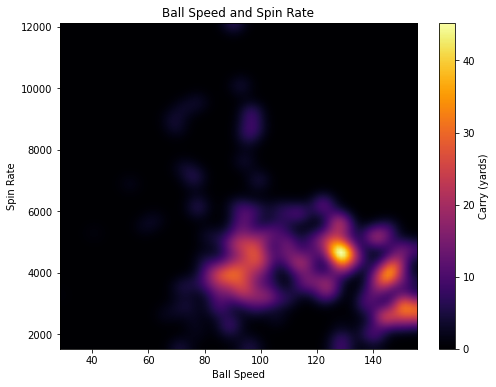

Optimal Ball Speed range: (np.float64(127.61599999999999), np.float64(128.88799999999998))
Optimal Spin Rate range: (np.float64(4604.9), np.float64(4711.0))


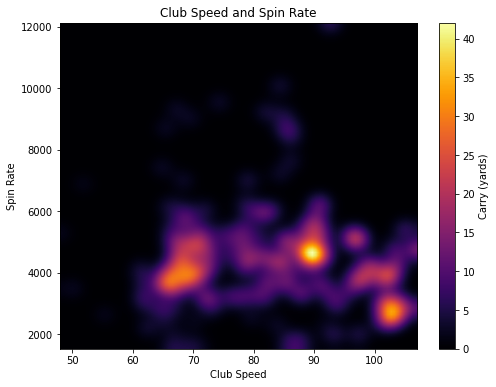

Optimal Club Speed range: (np.float64(89.27), np.float64(89.86099999999999))
Optimal Spin Rate range: (np.float64(4604.9), np.float64(4711.0))


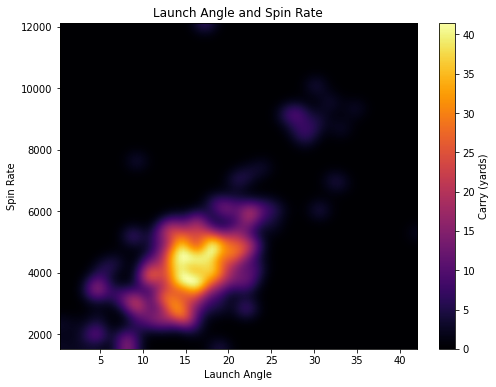

Optimal Launch Angle range: (np.float64(14.895000000000001), np.float64(15.312000000000001))
Optimal Spin Rate range: (np.float64(3756.1), np.float64(3862.2))


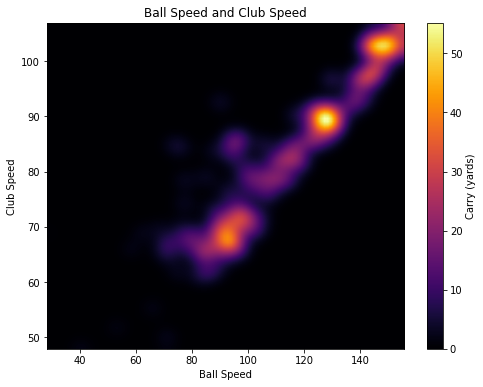

Optimal Ball Speed range: (np.float64(126.344), np.float64(127.61599999999999))
Optimal Club Speed range: (np.float64(89.27), np.float64(89.86099999999999))


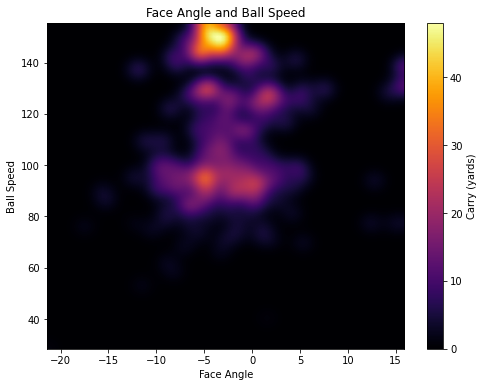

Optimal Face Angle range: (np.float64(-3.8689999999999998), np.float64(-3.4959999999999987))
Optimal Ball Speed range: (np.float64(149.23999999999998), np.float64(150.51199999999997))


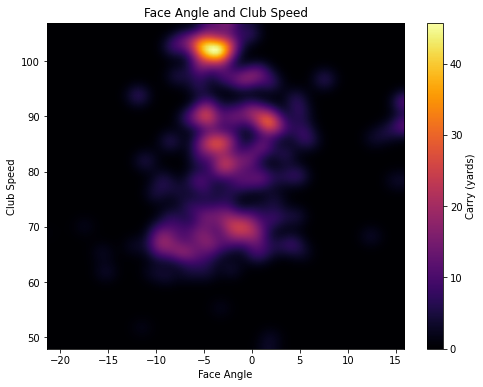

Optimal Face Angle range: (np.float64(-4.241999999999997), np.float64(-3.8689999999999998))
Optimal Club Speed range: (np.float64(101.681), np.float64(102.27199999999999))


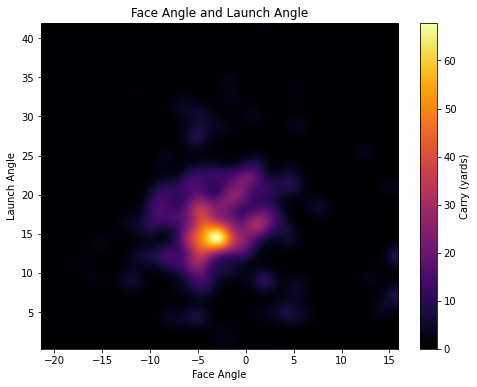

Optimal Face Angle range: (np.float64(-3.4959999999999987), np.float64(-3.1229999999999976))
Optimal Launch Angle range: (np.float64(14.478000000000002), np.float64(14.895000000000001))


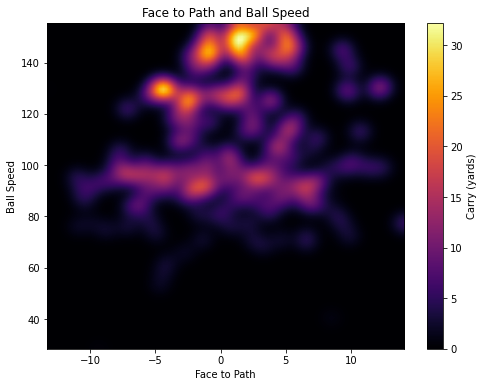

Optimal Face to Path range: (np.float64(1.2219999999999978), np.float64(1.4959999999999969))
Optimal Ball Speed range: (np.float64(147.968), np.float64(149.23999999999998))


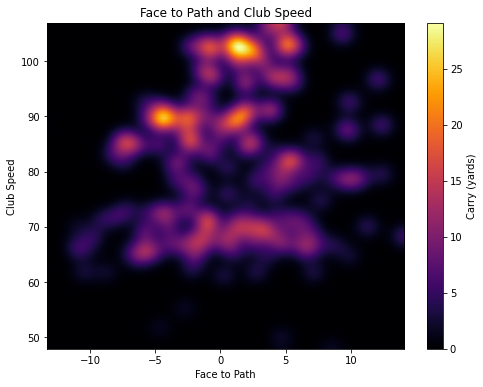

Optimal Face to Path range: (np.float64(1.2219999999999978), np.float64(1.4959999999999969))
Optimal Club Speed range: (np.float64(102.27199999999999), np.float64(102.863))


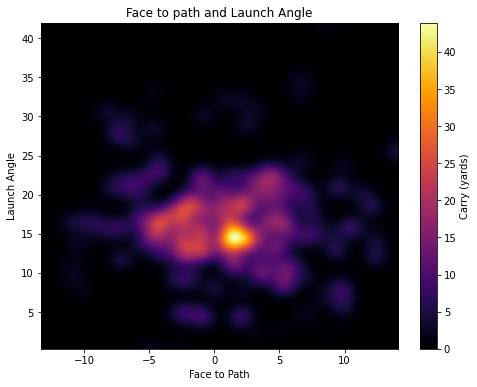

Optimal Face to Path range: (np.float64(1.4959999999999969), np.float64(1.7699999999999978))
Optimal Launch Angle range: (np.float64(14.478000000000002), np.float64(14.895000000000001))


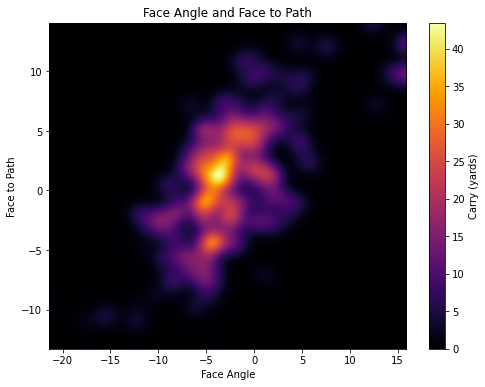

Optimal Face Angle range: (np.float64(-3.8689999999999998), np.float64(-3.4959999999999987))
Optimal Face to Path range: (np.float64(1.2219999999999978), np.float64(1.4959999999999969))


In [146]:
create_heatmap(df['Ball Speed'], df['Launch Angle'], df['Carry'], 'Ball Speed', 'Launch Angle', 'Ball Speed and Launch Angle')

create_heatmap(df['Club Speed'], df['Launch Angle'], df['Carry'], 'Club Speed', 'Launch Angle', 'Club Speed and Launch Angle')

create_heatmap(df['Ball Speed'], df['Spin Rate'], df['Carry'], 'Ball Speed', 'Spin Rate', 'Ball Speed and Spin Rate')

create_heatmap(df['Club Speed'], df['Spin Rate'], df['Carry'], 'Club Speed', 'Spin Rate', 'Club Speed and Spin Rate')

create_heatmap(df['Launch Angle'], df['Spin Rate'], df['Carry'], 'Launch Angle', 'Spin Rate', 'Launch Angle and Spin Rate')

create_heatmap(df['Ball Speed'], df['Club Speed'], df['Carry'], 'Ball Speed', 'Club Speed', 'Ball Speed and Club Speed')

create_heatmap(df['Face Angle'], df['Ball Speed'], df['Carry'], 'Face Angle', 'Ball Speed', 'Face Angle and Ball Speed')

create_heatmap(df['Face Angle'], df['Club Speed'], df['Carry'], 'Face Angle', 'Club Speed', 'Face Angle and Club Speed')

create_heatmap(df['Face Angle'], df['Launch Angle'], df['Carry'], 'Face Angle', 'Launch Angle', 'Face Angle and Launch Angle')

create_heatmap(df['Face to Path'], df['Ball Speed'], df['Carry'], 'Face to Path', 'Ball Speed', 'Face to Path and Ball Speed')

create_heatmap(df['Face to Path'], df['Club Speed'], df['Carry'], 'Face to Path', 'Club Speed', 'Face to Path and Club Speed')

create_heatmap(df['Face to Path'], df['Launch Angle'], df['Carry'], 'Face to Path', 'Launch Angle', 'Face to path and Launch Angle')

create_heatmap(df['Face Angle'], df['Face to Path'], df['Carry'], 'Face Angle', 'Face to Path', 'Face Angle and Face to Path')